## Importing modules

In [1]:
# import necessary modules
from threeML import Powerlaw
from cosipy import FastTSMap, SpacecraftHistory, MOCTSMap
from cosipy.response import FullDetectorResponse
import astropy.units as u
from histpy import Histogram
from astropy.time import Time
import numpy as np
from astropy.coordinates import SkyCoord
from pathlib import Path
from mhealpy import HealpixMap
from matplotlib import pyplot as plt
import gc
from cosipy.util import fetch_wasabi_file
import shutil
import os

import logging
logging.basicConfig(level = logging.INFO)
%matplotlib inline

04:47:27 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=1282933;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=1282934;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=1282940;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=1282941;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

04:47:28 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=1282948;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=1282949;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

04:47:30 INFO      Starting 3ML!                                                                     ]8;id=1282956;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=1282957;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=1282963;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=1282964;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   PyGMO is not available                                                      ]8;id=1283006;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=1283007;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=1283013;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=1283014;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

04:47:33 WARNING   No fermitools installed                                              ]8;id=1283021;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=1283022;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=1283028;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=1283029;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=1283034;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=1283035;file:///home/sheng2/Applications/conda_envs/cosipy_yong_dev/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Major inputs

In [2]:
GRB_name = "GRB_bn080802386"

raw_signal_file_name = "GRB_bn080802386_flux150_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

# This the true location of the GRB
coord = SkyCoord(l = 23.53, b = -53.44, unit = (u.deg, u.deg), frame = "galactic")

# this is the unbinned GRB start and end times
GRB_start_time_unbinned = 1835493492.2267933
GRB_end_time_unbinned =   1835493492.7676215

# this is the start and end of GRBs
GRB_start_time = GRB_start_time_unbinned #np.floor(GRB_start_time_unbinned)
GRB_end_time = GRB_end_time_unbinned #np.ceil(GRB_end_time_unbinned)

# bining options
time_bin_size = 0.1

### Define Paths

In [3]:
data_dir = Path("/project/majello/astrohe/yong/COSI/Data_Challenges/DC4") # Current directory by default. Modify if you want a different path

full_data_path = data_dir / f"{GRB_name}_binned.hdf5"

orientation_path = data_dir / "DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits"

response_path = data_dir / "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

unit_bkg = data_dir / "unit_bkg_binned.hdf5"

### Define a powerlaw spectrum

In [4]:
index = -2.2
K = 10 / u.cm / u.cm / u.s / u.keV
piv = 100 * u.keV
spectrum = Powerlaw()
spectrum.index.value = index
spectrum.K.value = K.value
spectrum.piv.value = piv.value 
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

### Read the data

In [5]:
# read the data, this includes GRB and background regions
full_data = Histogram.open(full_data_path)

# We want to use only the burst region in the LC
full_times = full_data.axes['Time'].edges.value

GRB_tmin_idx = np.searchsorted(full_times, GRB_start_time, side='left')
GRB_tmax_idx = np.searchsorted(full_times, GRB_end_time, side='right')

GRB_data = full_data.slice[GRB_tmin_idx:GRB_tmax_idx,:]  # It slices the Time axis

### Read the background model

In [6]:
bkg_model = Histogram.open(unit_bkg)*(GRB_end_time - GRB_start_time)

Text(0, 0.5, 'Counts')

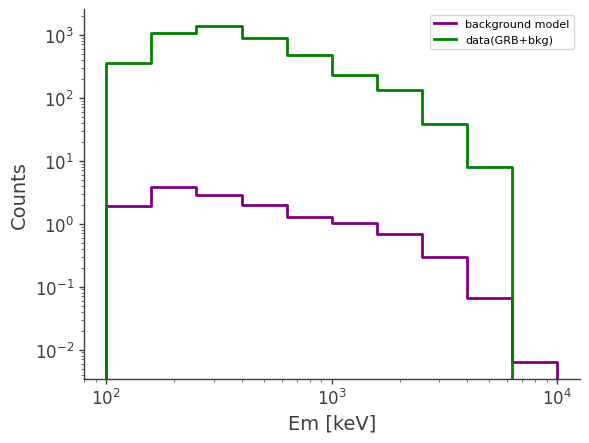

In [8]:
# plot the counts distribution
ax,plot = bkg_model.project("Em").draw(label = "background model", color = "purple")
GRB_data.project("Em").draw(ax, label = "data(GRB+bkg)", color = "green")

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")

#### Read the orientation

In [9]:
# read the full orientation but only get the interval for the GRB
ori_full = SpacecraftHistory.open(orientation_path)
grb_ori = ori_full.select_interval(Time(GRB_start_time, format = "unix"), Time(GRB_end_time, format = "unix"))

del ori_full

### Start MOC TS map fit

In [96]:
ts_map = MOCTSMap(
    data=GRB_data,
    bkg_model=bkg_model,
    response_path=response_path,
    orientation=grb_ori,
    cds_frame="local",
)

strategy = MOCTSMap.PaddingStrategy(
    MOCTSMap.ContainmentStrategy(0.97)
)

# strategy = MOCTSMap.PaddingStrategy(
#     MOCTSMap.TopKStrategy(k=12)
# )

In [97]:
%%time
moc_ts, moc_uniq = ts_map.fit(
    max_nside=512,
    init_nside=1,
    energy_channel=[0, 9],
    spectrum=spectrum,
    cpu_cores=64,
    strategy=strategy,
)

CPU times: user 1min 12s, sys: 3.67 s, total: 1min 16s
Wall time: 2.31 s


### Plot the fitted TS map

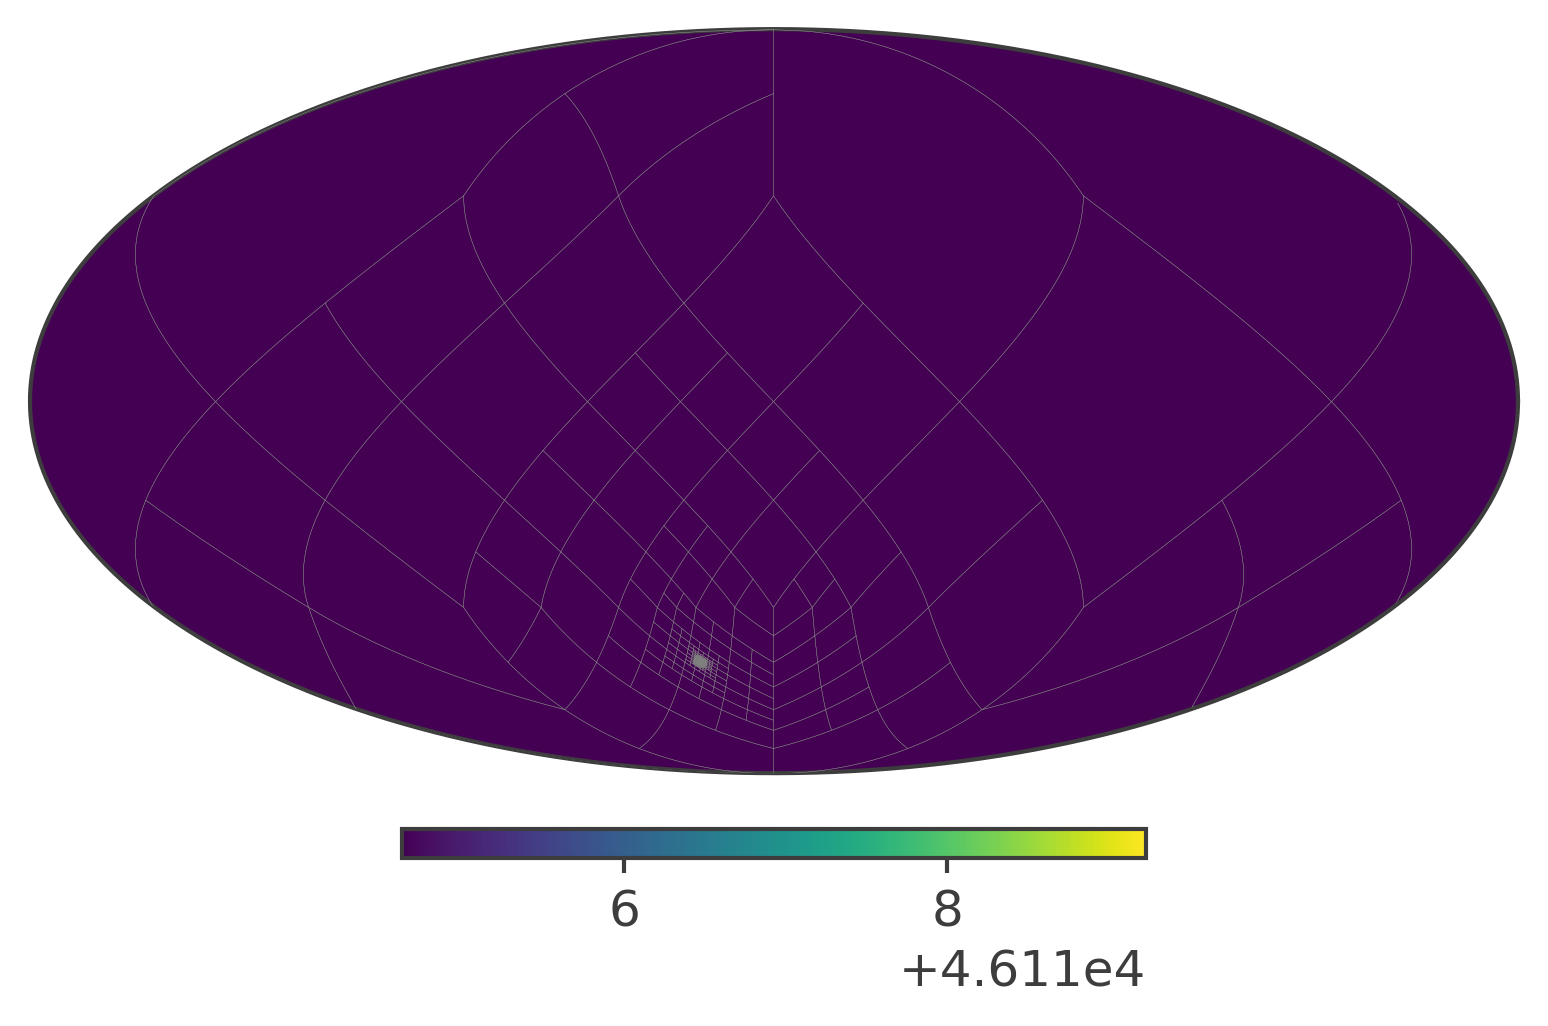

In [98]:
ts_map.plot_ts(
    moc_ts,
    moc_uniq,
    grid_lines=True,
    save_plot=True,
    containment=0.9,
)

In [99]:
m = HealpixMap(data = moc_ts, uniq = moc_uniq, scheme = "NESTED", coordsys = "G")

m.write_map("TS_Map.fits", overwrite=True)

# Fit GRB region

In [100]:
import scipy
from scipy.spatial import ConvexHull
from fit_ellipse import *

In [101]:
ts_map = HealpixMap.read_map("TS_Map.fits")
data = ts_map.data

In [102]:
# Find region pixels

critical = scipy.stats.chi2.ppf(0.90, df=2)

region_indices = np.where(data >= data.max() - critical)[0]

region_skycoord = ts_map.pix2skycoord(region_indices)

region_peak = data[region_indices].max()

In [103]:
# Find convex hull coordinates

# coordinates array
coords = np.array([region_skycoord.l.deg, region_skycoord.b.deg]).T

hull = ConvexHull(coords, incremental = True)

edge_pixels = coords[hull.vertices]
edge_skycoord = SkyCoord(l = edge_pixels[:,0], b = edge_pixels[:,1], unit = "deg", frame = "galactic")
edge_skycoord

<SkyCoord (Galactic): (l, b) in deg
    [(26.06493506, -54.24491886), (25.66496164, -53.66841021),
     (25.07633588, -53.47602978), (24.38931298, -53.47602978),
     (23.99234694, -53.57223328), (23.65384615, -53.76456066),
     (23.54381443, -53.95678248), (23.49350649, -54.24491886),
     (23.5546875 , -54.3409123 ), (23.61618799, -54.4368799 ),
     (23.67801047, -54.53282172), (24.03947368, -54.72462841),
     (24.34036939, -54.82049345), (25.29023747, -54.82049345),
     (25.46052632, -54.72462841), (25.62992126, -54.62873786),
     (25.79842932, -54.53282172), (25.96605744, -54.4368799 )]>

In [104]:
# Fit the ellipse

l_center, b_center = ts_map.pix2ang(np.where(data == data.max())[0][0], lonlat = True)
center_skycoord = SkyCoord(l_center, b_center, unit = "deg", frame = "galactic")

center_init = center_skycoord
a_init = 0.01
b_init = 0.01
theta_init = 45

fit = FitSphericalEllipse(edge_coords = edge_skycoord,
                          skycoord_init = center_init, 
                          semi_major_init = a_init, 
                          semi_minor_init = b_init, 
                          theta_init = theta_init)

_ = fit.fit_ellipse()
_

center_coord, semi_major_axis, semi_minor_axis, theta = fit.ellipse_param

Fitted Center (l, b): (24.76, -54.15)
Fitted Axes (a, b): (0.75 deg, 0.71 deg)
Fitted Position Angle θ: 87.82 deg


In [105]:
ellipse_edge = fit.get_ellipse_edge(npoints = 1000)

results_array = np.array([center_coord.l.deg, center_coord.b.deg, semi_major_axis, semi_minor_axis, theta, region_peak])
np.savetxt("Ellipse_result.txt", results_array, header = "Center lon, Center_lat, a, b, theta, region_ts_peak", fmt="%.8f")

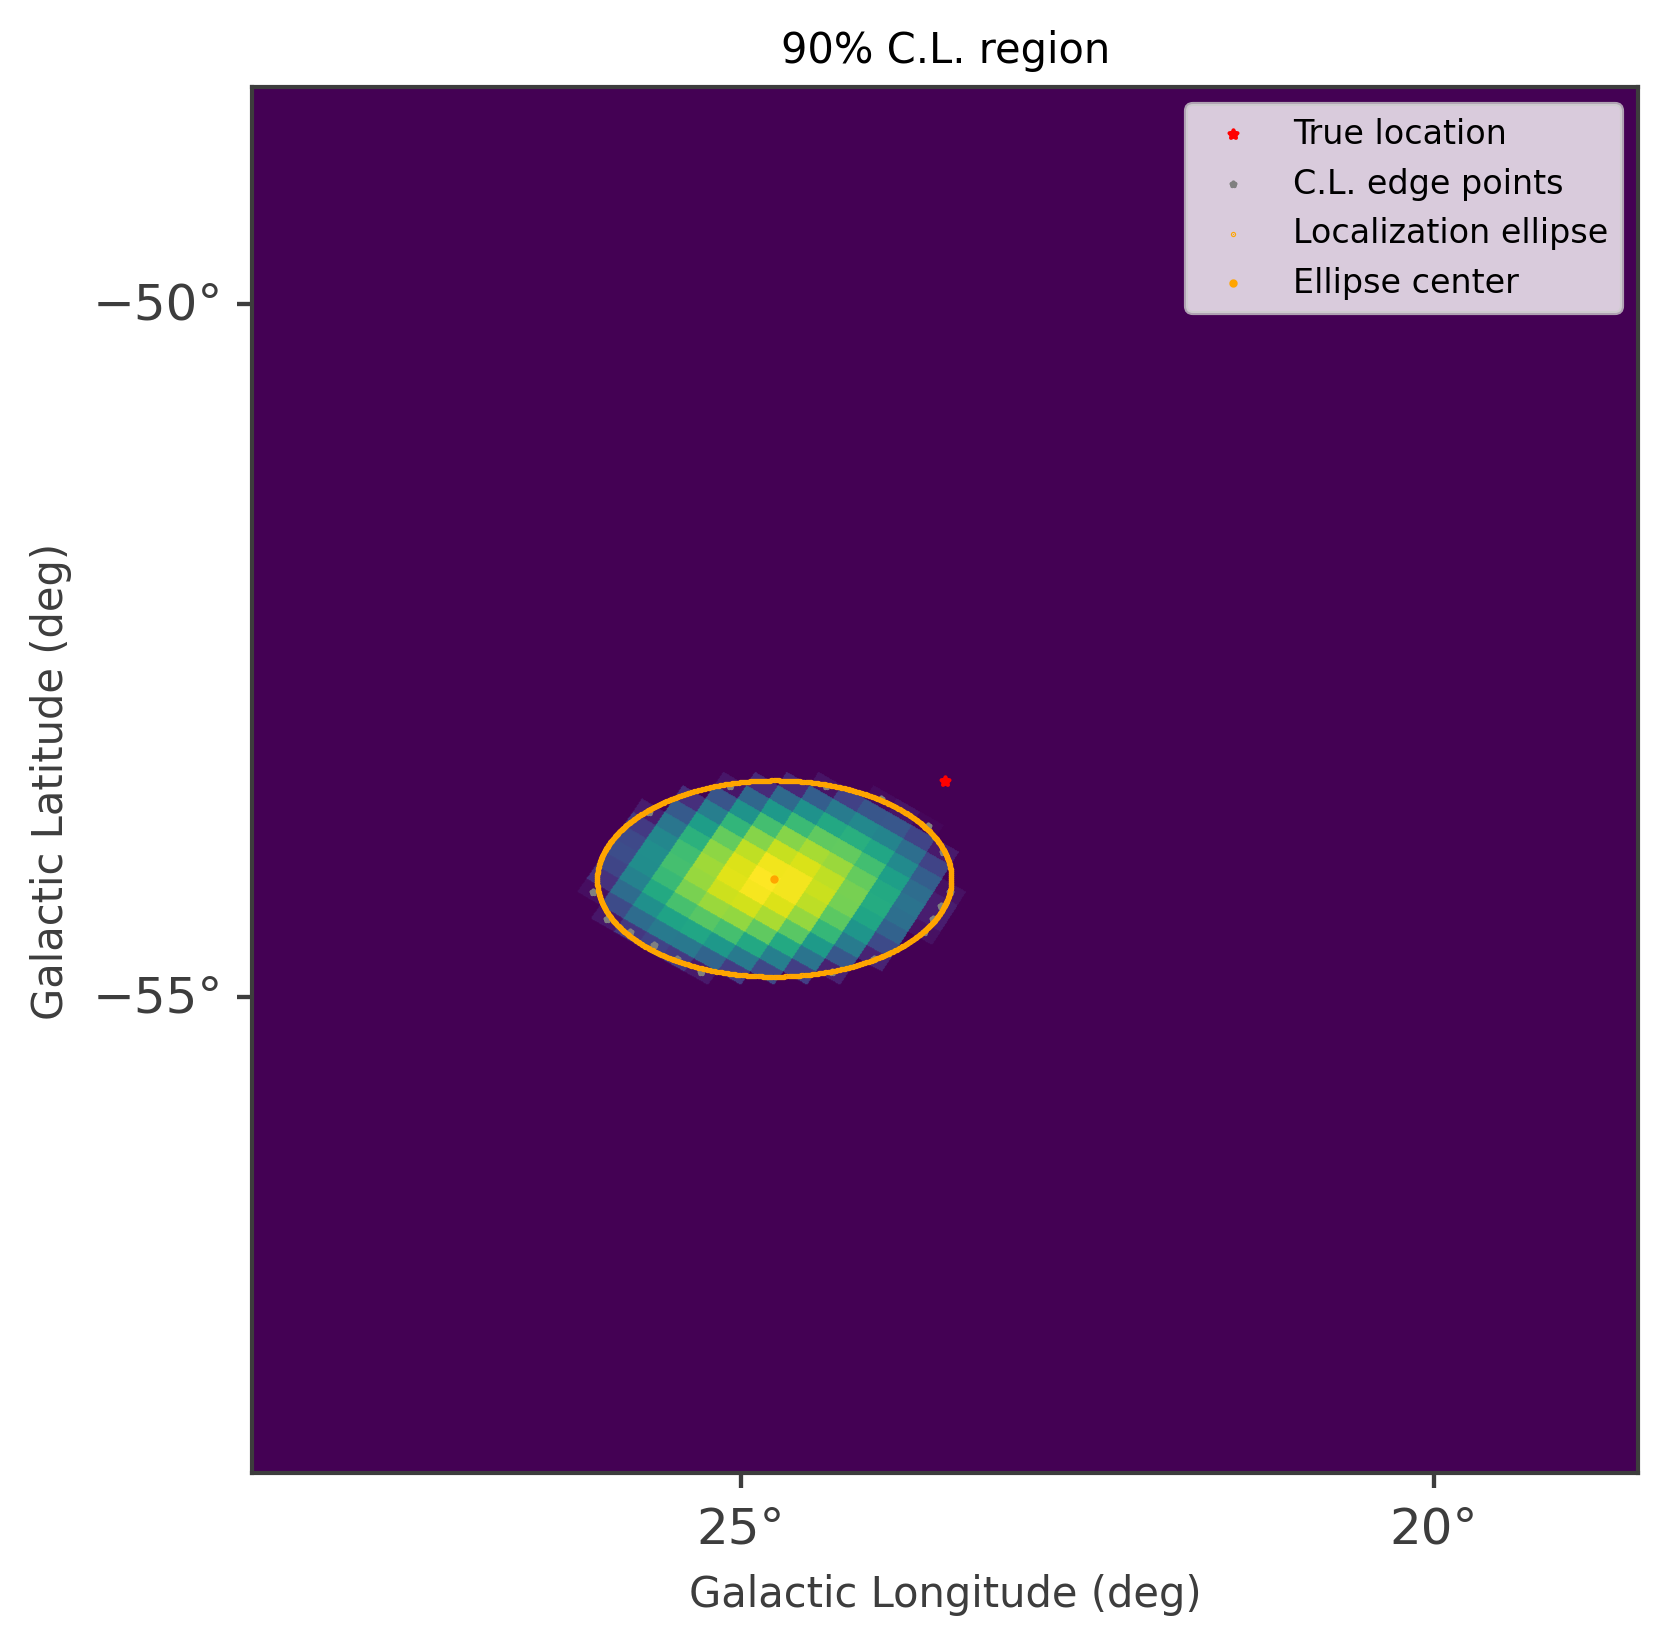

In [106]:
# Plot the ellipse

# zoom in

critical = scipy.stats.chi2.ppf(0.9, df=2)

fig = plt.figure(figsize = (6, 6), dpi = 300)

# lonra = [260,280]
# latra = [-90,-80]

lonra = coord.l.deg + [-5, 5]
latra = coord.b.deg + [-5, 5]

axCart = fig.add_subplot(projection = "cartview", lonra = lonra, latra = latra)
axCart.set_title("90% C.L. region", size = 10)

max_ts = np.max(ts_map[:])
plotCart, projCart = ts_map.plot(axCart, vmin = max_ts-critical, vmax = max_ts, ax_kw = {'coord':'G'}, coord = "C", cbar = False);

axCart.scatter(coord.l.deg, coord.b.deg, s = 4, marker = "*", 
               transform = axCart.get_transform('world'), color = "red", label = "True location")

axCart.scatter(edge_pixels[:,0], edge_pixels[:,1], s = 1, marker = "*",
               transform = axCart.get_transform('world'), color = "gray", label = "C.L. edge points")

axCart.scatter(ellipse_edge.l.deg, ellipse_edge.b.deg, s = 0.3, marker = ".",
               transform = axCart.get_transform('world'), color = "orange", label = "Localization ellipse")

axCart.scatter(center_coord.l.deg, center_coord.b.deg, s = 4, marker = ".",
               transform = axCart.get_transform('world'), color = "orange", label = "Ellipse center")

axCart.set_xlabel("Galactic Longitude (deg)", fontsize=10)
axCart.set_ylabel("Galactic Latitude (deg)", fontsize=10)

axCart.coords[0].set_ticks_visible(True)  # Enable longitude ticks
axCart.coords[1].set_ticks_visible(True)  # Enable latitude ticks
axCart.coords[0].set_ticklabel_visible(True)  # Show longitude tick labels
axCart.coords[1].set_ticklabel_visible(True)  # Show latitude tick labels

# Set tick positions to remove top and right ticks
axCart.coords[0].set_ticks_position('b')  # Longitude ticks only at the bottom
axCart.coords[1].set_ticks_position('l')  # Latitude ticks only at the left

axCart.coords[0].set_ticklabel_position('b')  # Longitude labels only at the bottom
axCart.coords[1].set_ticklabel_position('l')  # Latitude labels only at the left

# Set tick spacing and format
axCart.coords[0].set_ticks(spacing=5 * u.deg)  # Longitude tick spacing to 5 degrees
axCart.coords[1].set_ticks(spacing=5 * u.deg)  # Latitude tick spacing to 5 degrees
axCart.coords[0].set_major_formatter('d')  # Format as degrees for longitude
axCart.coords[1].set_major_formatter('d')  # Format as degrees for latitude

#cbar = plt.colorbar(plotCart, ax=axCart, orientation='vertical', fraction=0.05, pad=0.02, label = "TS")

# Show grid
#ts_map.plot_grid(axCart, color='gray', linewidth = .01, ax_kw = {'coord':'G'}, coord = "C")

plt.legend()

fig.savefig(f"TS_Map_with_Ellipse_fitting.png", dpi=150, bbox_inches="tight")